# Scenario 2: Airplane Crash Fatalities Prediction

## Objective

This notebook develops a complete regression pipeline to predict the number of fatalities in historical airplane crash records.

The target variable is:

```text
Fatalities
```

The required final output is a CSV file with one column:

```text
Predictions
```

The final predictions file is saved in the same folder as this notebook.

## 1. Import libraries

In [3]:
from pathlib import Path
import inspect
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_JOBS = -1

sns.set_theme(style="whitegrid")

## 2. File paths

The input files are loaded using relative paths from the notebook folder.

Expected folder structure:

```text
Processed_datasets/
└── Airplanes/
    ├── Airplane_Crashes_and_Fatalities_Since_1908_data.csv
    └── Airplane_Crashes_and_Fatalities_Since_1908_unseen.csv
```

The final predictions CSV is saved in the same folder as this notebook.

In [5]:
BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / "Processed_datasets" / "Airplanes"

TRAIN_PATH = DATASET_DIR / "Airplane_Crashes_and_Fatalities_Since_1908_data.csv"
UNSEEN_PATH = DATASET_DIR / "Airplane_Crashes_and_Fatalities_Since_1908_unseen.csv"

PREDICTIONS_PATH = BASE_DIR / "Fenner_Backhouse_scenario_2.csv"

print("Training path:", TRAIN_PATH)
print("Unseen path:", UNSEEN_PATH)
print("Predictions output path:", PREDICTIONS_PATH)

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Training file not found: {TRAIN_PATH}")

if not UNSEEN_PATH.exists():
    raise FileNotFoundError(f"Unseen file not found: {UNSEEN_PATH}")

Training path: C:\Users\fenne\Documents\Rockborne_training\DS_Proj1\Processed_datasets\Airplanes\Airplane_Crashes_and_Fatalities_Since_1908_data.csv
Unseen path: C:\Users\fenne\Documents\Rockborne_training\DS_Proj1\Processed_datasets\Airplanes\Airplane_Crashes_and_Fatalities_Since_1908_unseen.csv
Predictions output path: C:\Users\fenne\Documents\Rockborne_training\DS_Proj1\Fenner_Backhouse_scenario_2.csv


## 3. Load the data

In [7]:
train_df = pd.read_csv(TRAIN_PATH)
unseen_df = pd.read_csv(UNSEEN_PATH)

print("Training data shape:", train_df.shape)
print("Unseen data shape:", unseen_df.shape)

display(train_df.head())
display(unseen_df.head())

Training data shape: (4741, 13)
Unseen data shape: (527, 12)


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
1,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
2,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
3,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land af...
4,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,19.0,0.0,"Exploded and burned near Neuwerk Island, when..."


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Ground,Summary
0,10/24/2004,16:30,"Martinsville, Virginia",Private - Hendrick Motorsports Inc.,NaN,"Concord, NC - Martinsville, VA",Beech 200 Super King Air,N501RH,BB-805,10.0,0.0,The plane struck a steep incline in the Bull M...
1,08/09/1954,00:08,"Terceira Island, Azores, Portugal",AVIANCA,NaN,"Lajes, Azores - Bermuda",Lockheed 749A-79 Constellation,HK-163,2664,30.0,0.0,Crashed into mountains after poor weather dive...
2,12/02/1977,NaN,"Near Al Bayda, Lebanon",Balkan Bulgarian Airlines,NaN,Jeddah - Benghazi,Tupolev TU-154B,LZ-BTN,054,165.0,0.0,After not being able to land at the scheduled ...
3,11/02/1988,NaN,"Near Rzeszow, Poland",LOT Polish Airlines,703,Warszawa - Rzeszow,Antonov AN-24B,SP-LTD,67302209,29.0,0.0,The plane attempted to make an emergency landi...
4,08/15/1957,NaN,"Copenhagen, Denmark",Aeroflot,NaN,Riga - Copenhagen,Ilyushin IL-14P,CCCP-L1874,146000607,23.0,0.0,Crashed into the harbor after hitting the chim...


## 4. Initial data checks

This section checks the structure of the training and unseen datasets before modelling.

In [9]:
TARGET = "Fatalities"

assert TARGET in train_df.columns, "The training data must contain the target column."
assert TARGET not in unseen_df.columns, "The unseen data should not contain the target column."

feature_cols = [col for col in train_df.columns if col != TARGET]

assert set(feature_cols) == set(unseen_df.columns), "Training and unseen feature columns do not match."

# Align unseen columns to match the training feature order.
unseen_df = unseen_df[feature_cols]

print("Training columns:")
print(train_df.columns.tolist())

print("\nUnseen columns:")
print(unseen_df.columns.tolist())

print("\nTraining data types:")
display(train_df.dtypes)

print("\nMissing values in training data:")
display(train_df.isna().sum().sort_values(ascending=False))

print("\nMissing values in unseen data:")
display(unseen_df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in unseen data:", unseen_df.duplicated().sum())

Training columns:
['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Fatalities', 'Ground', 'Summary']

Unseen columns:
['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Ground', 'Summary']

Training data types:


Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object


Missing values in training data:


Flight #        3774
Time            2000
Route           1545
cn/In           1098
Summary          353
Registration     300
Type              24
Ground            20
Aboard            19
Location          17
Operator          15
Fatalities        11
Date               0
dtype: int64


Missing values in unseen data:


Flight #        425
Time            219
Route           162
cn/In           130
Summary          37
Registration     35
Location          3
Operator          3
Type              3
Aboard            3
Ground            2
Date              0
dtype: int64


Duplicate rows in training data: 0
Duplicate rows in unseen data: 0


## 5. Clean target variable

Rows with missing `Fatalities` cannot be used for supervised regression, so they are removed.

Missing predictor values are not removed here. They are handled inside the preprocessing pipeline to ensure the same approach is applied to training, validation and unseen data.

In [11]:
rows_before = len(train_df)
train_df = train_df.dropna(subset=[TARGET]).copy()
rows_after = len(train_df)

print("Rows before removing missing target:", rows_before)
print("Rows after removing missing target:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before removing missing target: 4741
Rows after removing missing target: 4730
Rows removed: 11


## 6. Target variable analysis

count    4730.000000
mean       20.009725
std        33.142890
min         0.000000
25%         3.000000
50%         9.000000
75%        22.000000
max       583.000000
Name: Fatalities, dtype: float64

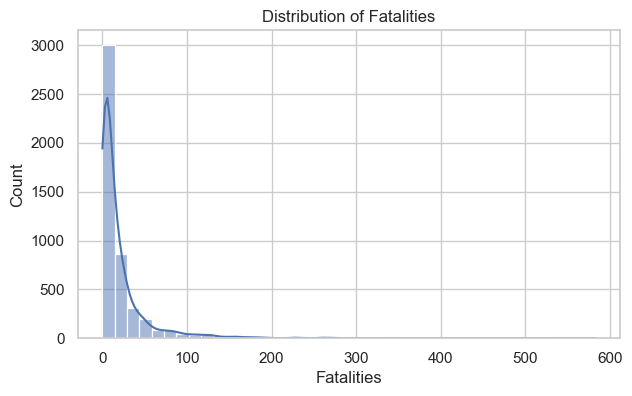

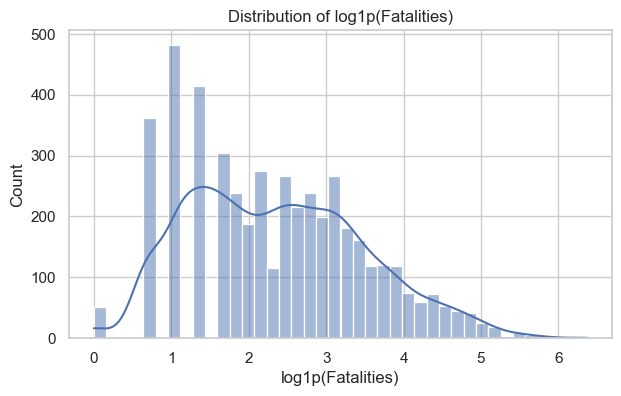

In [13]:
display(train_df[TARGET].describe())

plt.figure(figsize=(7, 4))
sns.histplot(train_df[TARGET], bins=40, kde=True)
plt.title("Distribution of Fatalities")
plt.xlabel("Fatalities")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(train_df[TARGET]), bins=40, kde=True)
plt.title("Distribution of log1p(Fatalities)")
plt.xlabel("log1p(Fatalities)")
plt.ylabel("Count")
plt.show()

The target distribution is right-skewed. For this reason, both raw-target and log-target regression models are considered during model comparison.

## 7. Exploratory data analysis

,Aboard,Ground,Fatalities
count,4722.000000,4721.000000,4730.000000
mean,27.721093,1.766575,20.009725
std,43.613847,56.906906,33.142890
min,0.000000,0.000000,0.000000
25%,5.000000,0.000000,3.000000
50%,13.000000,0.000000,9.000000
75%,30.000000,0.000000,22.000000
max,644.000000,2750.000000,583.000000


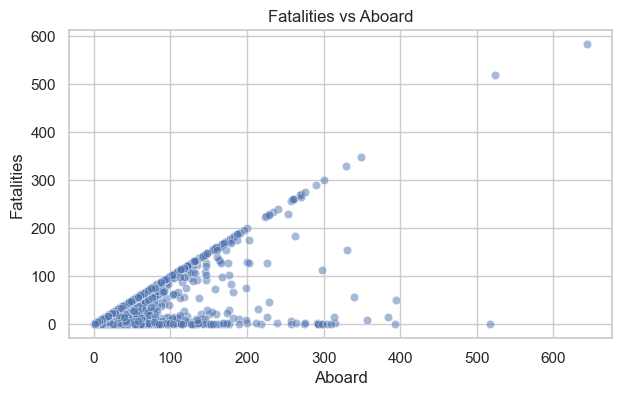

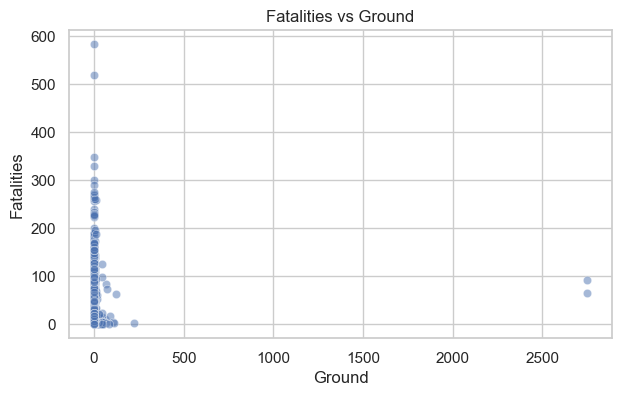

Parsed date missing count: 0
Year range: 1912 to 2009


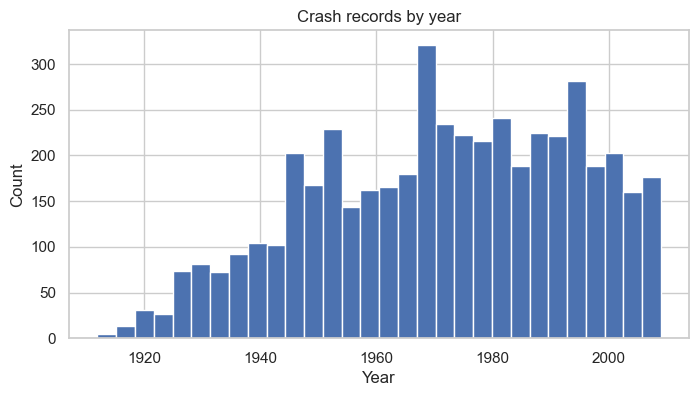


Location:
Missing values: 16
Unique values: 3912


Location
NaN                       16
Rio de Janeiro, Brazil    14
Moscow, Russia            13
Manila, Philippines       13
Anchorage, Alaska         12
Sao Paulo, Brazil         12
Bogota, Colombia          11
Cairo, Egypt              11
New York, New York        11
Chicago, Illinois         10
Name: count, dtype: int64


Operator:
Missing values: 15
Unique values: 2288


Operator
Aeroflot                           160
Military - U.S. Air Force          160
Air France                          62
Deutsche Lufthansa                  61
Military - U.S. Army Air Forces     42
Air Taxi                            40
United Air Lines                    40
Pan American World Airways          36
American Airlines                   34
Indian Airlines                     34
Name: count, dtype: int64


Route:
Missing values: 1535
Unique values: 2923


Route
NaN                           1535
Training                        73
Sightseeing                     27
Test flight                     16
Test                             5
Bogota - Barranquilla            4
Sao Paulo - Rio de Janeiro       4
Sao Paulo - Porto Alegre         4
Rio de Janeiro - Sao Paulo       3
Hue - Da Nang                    3
Name: count, dtype: int64


Type:
Missing values: 23
Unique values: 2267


Type
Douglas DC-3                                289
de Havilland Canada DHC-6 Twin Otter 300     70
Douglas C-47A                                67
Douglas C-47                                 57
Douglas DC-4                                 35
Antonov AN-26                                33
Yakovlev YAK-40                              33
Junkers JU-52/3m                             31
Douglas C-47B                                26
De Havilland DH-4                            26
Name: count, dtype: int64


Summary:
Missing values: 348
Unique values: 4206


Summary
NaN                                        348
Crashed during takeoff.                     13
Crashed into a mountain.                    11
Struck a mountain.                          11
Crashed into the sea.                       11
Crashed shortly after taking off.           10
Crashed on takeoff.                         10
Crashed while en route.                      9
Crashed into a mountain while en route.      8
Flew into a mountain.                        7
Name: count, dtype: int64

In [16]:
numeric_raw_cols = ["Aboard", "Ground"]

display(train_df[numeric_raw_cols + [TARGET]].describe())

for col in numeric_raw_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=train_df, x=col, y=TARGET, alpha=0.5)
    plt.title(f"{TARGET} vs {col}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.show()

parsed_date = pd.to_datetime(train_df["Date"], format="%m/%d/%Y", errors="coerce")

print("Parsed date missing count:", parsed_date.isna().sum())
print("Year range:", parsed_date.dt.year.min(), "to", parsed_date.dt.year.max())

plt.figure(figsize=(8, 4))
parsed_date.dt.year.hist(bins=30)
plt.title("Crash records by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

text_and_categorical_cols = ["Location", "Operator", "Route", "Type", "Summary"]

for col in text_and_categorical_cols:
    print(f"\n{col}:")
    print("Missing values:", train_df[col].isna().sum())
    print("Unique values:", train_df[col].nunique(dropna=True))
    display(train_df[col].value_counts(dropna=False).head(10))

The raw dataset contains a mixture of numeric, categorical, date, time and text fields. Some columns contain many unique values or missing values, so the modelling pipeline uses automated preprocessing rather than manual row removal.

## 8. Feature engineering functions

The feature engineering step converts raw fields into structured modelling features.

Main transformations:

- Date features from `Date`
- Hour and time-of-day indicators from `Time`
- Log-transformed exposure variables from `Aboard` and `Ground`
- Region and broad-region features from `Location`
- Interpretable location flags
- Aircraft family from `Type`
- Route complexity features from `Route`
- Operator flags
- Summary keyword flags
- Cleaned `Summary` text for TF-IDF tokenisation

The `Summary` text is retained because it is available in both the training and unseen datasets. Since it is a post-accident description, it may contain target-related wording, so the results should be interpreted with that context in mind. Numeric tokens are removed before TF-IDF is applied.

In [19]:
def extract_time_hour(time_value):
    if pd.isna(time_value):
        return np.nan

    text = str(time_value).strip()
    match = re.search(r"(\d{1,2})[:.]?(\d{2})", text)

    if match is None:
        return np.nan

    hour = int(match.group(1))

    if 0 <= hour <= 23:
        return hour

    return np.nan


def contains_any(text_series, keywords):
    pattern = "|".join(keywords)
    return text_series.str.contains(pattern, case=False, regex=True, na=False).astype(int)


def clean_text_for_tfidf(series):
    series = pd.Series(series).fillna("").astype(str)
    series = series.str.replace(r"\b\d+\b", " ", regex=True)
    series = series.str.replace(r"[^A-Za-z\s\-]", " ", regex=True)
    series = series.str.replace(r"\s+", " ", regex=True).str.strip()
    return series


def standardise_region(value):
    if pd.isna(value):
        return "Unknown"

    text = str(value).strip()

    if text == "":
        return "Unknown"

    lower = text.lower()

    replacements = {
        "u.s.a.": "USA",
        "usa": "USA",
        "united states": "USA",
        "united states of america": "USA",
        "uk": "United Kingdom",
        "england": "United Kingdom",
        "scotland": "United Kingdom",
        "ussr": "Russia",
        "soviet union": "Russia",
        "zaire": "DR Congo"
    }

    return replacements.get(lower, text)


def broad_region_from_location(region):
    if pd.isna(region):
        return "Unknown"

    r = str(region).lower()

    americas = [
        "usa", "canada", "mexico", "brazil", "argentina", "colombia", "chile",
        "peru", "venezuela", "bolivia", "ecuador", "cuba", "panama",
        "guatemala", "honduras", "nicaragua", "jamaica", "puerto rico",
        "bahamas", "costa rica", "dominican republic", "uruguay", "paraguay",
        "el salvador", "alaska"
    ]

    europe = [
        "united kingdom", "france", "germany", "spain", "italy", "russia",
        "poland", "netherlands", "norway", "sweden", "finland", "belgium",
        "switzerland", "austria", "portugal", "greece", "ireland", "denmark",
        "romania", "ukraine", "yugoslavia", "czechoslovakia"
    ]

    asia = [
        "china", "india", "japan", "indonesia", "philippines", "vietnam",
        "thailand", "pakistan", "iran", "iraq", "turkey", "nepal",
        "afghanistan", "malaysia", "korea", "sri lanka", "bangladesh",
        "burma", "myanmar", "taiwan"
    ]

    africa = [
        "south africa", "nigeria", "egypt", "kenya", "ethiopia", "sudan",
        "libya", "morocco", "algeria", "angola", "congo", "dr congo",
        "tanzania", "ghana", "cameroon", "zimbabwe", "uganda", "mozambique"
    ]

    oceania = [
        "australia", "new zealand", "papua new guinea", "fiji"
    ]

    if any(x in r for x in americas):
        return "Americas"
    if any(x in r for x in europe):
        return "Europe"
    if any(x in r for x in asia):
        return "Asia"
    if any(x in r for x in africa):
        return "Africa"
    if any(x in r for x in oceania):
        return "Oceania"
    if "ocean" in r or "sea" in r or "atlantic" in r or "pacific" in r or "indian" in r:
        return "Ocean/Sea"

    return "Other/Unknown"


def make_airplane_features(df):
    df = df.copy()

    parsed_date = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")
    df["crash_year"] = parsed_date.dt.year
    df["crash_month"] = parsed_date.dt.month
    df["crash_dayofweek"] = parsed_date.dt.dayofweek
    df["crash_decade"] = (parsed_date.dt.year // 10) * 10
    df["years_since_1908"] = df["crash_year"] - 1908
    df["date_missing"] = parsed_date.isna().astype(int)

    df["crash_hour"] = df["Time"].apply(extract_time_hour)
    df["time_missing"] = df["crash_hour"].isna().astype(int)
    df["night_flag"] = df["crash_hour"].between(0, 5).fillna(False).astype(int)
    df["daytime_flag"] = df["crash_hour"].between(6, 17).fillna(False).astype(int)

    df["aboard_log1p"] = np.log1p(df["Aboard"])
    df["ground_log1p"] = np.log1p(df["Ground"])
    df["total_exposed"] = df["Aboard"].fillna(0) + df["Ground"].fillna(0)
    df["total_exposed_log1p"] = np.log1p(df["total_exposed"])
    df["ground_to_aboard_ratio"] = df["Ground"] / (df["Aboard"] + 1)
    df["aboard_missing"] = df["Aboard"].isna().astype(int)
    df["ground_missing"] = df["Ground"].isna().astype(int)

    location_text = df["Location"].fillna("").astype(str)
    summary_text = df["Summary"].fillna("").astype(str)
    combined_location_summary = location_text + " " + summary_text

    region = location_text.str.split(",").str[-1].str.strip()
    df["location_region"] = region.apply(standardise_region)
    df["broad_region"] = df["location_region"].apply(broad_region_from_location)
    df["location_missing"] = df["Location"].isna().astype(int)
    df["location_token_count"] = location_text.str.split().str.len()

    water_keywords = [
        "sea", "ocean", "atlantic", "pacific", "indian ocean", "mediterranean",
        "channel", "gulf", "bay", "lake", "river", "water", "off coast",
        "near coast", "harbor", "harbour"
    ]

    remote_keywords = [
        "mountain", "jungle", "forest", "desert", "island", "ridge",
        "terrain", "hills"
    ]

    df["over_water_flag"] = contains_any(combined_location_summary, water_keywords)
    df["remote_terrain_flag"] = contains_any(combined_location_summary, remote_keywords)

    df["location_near_flag"] = contains_any(location_text, [r"\bnear\b"])
    df["location_over_flag"] = contains_any(location_text, [r"\bover\b"])
    df["location_off_flag"] = contains_any(location_text, [r"\boff\b"])
    df["location_between_flag"] = contains_any(location_text, [r"\bbetween\b"])
    df["location_airport_flag"] = contains_any(combined_location_summary, ["airport", "airfield", "runway"])

    type_text = df["Type"].fillna("Unknown").astype(str).str.strip()
    df["aircraft_family"] = type_text.str.extract(r"^([A-Za-z0-9\-]+)", expand=False).fillna("Unknown")
    df["type_missing"] = df["Type"].isna().astype(int)

    route_text = df["Route"].fillna("").astype(str)
    df["route_missing"] = df["Route"].isna().astype(int)
    df["route_length"] = route_text.str.len()
    df["route_stop_count"] = route_text.str.count("-|/|,")

    operator_text = df["Operator"].fillna("").astype(str)
    df["operator_missing"] = df["Operator"].isna().astype(int)
    df["operator_military_flag"] = contains_any(
        operator_text,
        ["military", "air force", "navy", "army", "marines", "u.s.", "usaf", "raf"]
    )
    df["operator_private_flag"] = contains_any(
        operator_text,
        ["private", "charter", "taxi"]
    )

    df["summary_missing"] = df["Summary"].isna().astype(int)
    df["summary_length"] = summary_text.str.len()
    df["summary_word_count"] = summary_text.str.split().str.len()

    df["summary_weather_flag"] = contains_any(
        summary_text,
        ["weather", "storm", "fog", "rain", "snow", "icing", "wind", "thunder"]
    )
    df["summary_fire_flag"] = contains_any(
        summary_text,
        ["fire", "flame", "burn", "smoke"]
    )
    df["summary_engine_flag"] = contains_any(
        summary_text,
        ["engine", "mechanical", "failure", "malfunction"]
    )
    df["summary_landing_takeoff_flag"] = contains_any(
        summary_text,
        ["takeoff", "take-off", "landing", "landed", "approach", "runway"]
    )
    df["summary_collision_flag"] = contains_any(
        summary_text,
        ["collision", "collided", "midair", "mid-air"]
    )
    df["summary_terrain_flag"] = contains_any(
        summary_text,
        ["mountain", "terrain", "hill", "ridge", "trees"]
    )
    df["summary_explosion_flag"] = contains_any(
        summary_text,
        ["explosion", "exploded", "bomb"]
    )
    df["summary_survival_flag"] = contains_any(
        summary_text,
        ["survivor", "survived", "rescued", "escaped"]
    )
    df["summary_all_aboard_flag"] = contains_any(
        summary_text,
        ["all aboard", "all occupants", "everyone aboard"]
    )

    df["summary_clean"] = clean_text_for_tfidf(summary_text)

    return df

## 9. Feature engineering checks

This section shows how the data changes after feature engineering.

In [21]:
engineered_preview = make_airplane_features(train_df.drop(columns=[TARGET]))

print("Raw training feature shape:", train_df.drop(columns=[TARGET]).shape)
print("After feature engineering shape:", engineered_preview.shape)

new_cols = [col for col in engineered_preview.columns if col not in feature_cols]

print("\nNumber of engineered columns added:", len(new_cols))
print("Engineered columns:")
print(new_cols)

display(engineered_preview[new_cols].head())

Raw training feature shape: (4730, 12)
After feature engineering shape: (4730, 61)

Number of engineered columns added: 49
Engineered columns:
['crash_year', 'crash_month', 'crash_dayofweek', 'crash_decade', 'years_since_1908', 'date_missing', 'crash_hour', 'time_missing', 'night_flag', 'daytime_flag', 'aboard_log1p', 'ground_log1p', 'total_exposed', 'total_exposed_log1p', 'ground_to_aboard_ratio', 'aboard_missing', 'ground_missing', 'location_region', 'broad_region', 'location_missing', 'location_token_count', 'over_water_flag', 'remote_terrain_flag', 'location_near_flag', 'location_over_flag', 'location_off_flag', 'location_between_flag', 'location_airport_flag', 'aircraft_family', 'type_missing', 'route_missing', 'route_length', 'route_stop_count', 'operator_missing', 'operator_military_flag', 'operator_private_flag', 'summary_missing', 'summary_length', 'summary_word_count', 'summary_weather_flag', 'summary_fire_flag', 'summary_engine_flag', 'summary_landing_takeoff_flag', 'summary

,crash_year,crash_month,crash_dayofweek,crash_decade,years_since_1908,date_missing,crash_hour,time_missing,night_flag,daytime_flag,...,summary_weather_flag,summary_fire_flag,summary_engine_flag,summary_landing_takeoff_flag,summary_collision_flag,summary_terrain_flag,summary_explosion_flag,summary_survival_flag,summary_all_aboard_flag,summary_clean
0,1912,7,4,1910,4,0,6.0,0,0,1,...,0,0,0,0,0,0,1,0,0,First U S dirigible Akron exploded just offsho...
1,1913,8,2,1910,5,0,NaN,1,0,0,...,1,0,0,0,0,0,0,0,0,The first fatal airplane accident in Canada oc...
2,1913,9,1,1910,5,0,18.0,0,0,0,...,1,0,0,0,0,0,0,0,0,The airship flew into a thunderstorm and encou...
3,1915,3,4,1910,7,0,1.0,0,1,0,...,0,0,0,0,0,1,0,0,0,Crashed into trees while attempting to land af...
4,1915,9,4,1910,7,0,15.0,0,0,1,...,0,1,0,0,0,0,1,0,0,Exploded and burned near Neuwerk Island when h...


## 10. Location flag diagnostics

Location flags are included as simple proxy features for crash context. They do not directly cause fatalities, but they can capture patterns in how crash locations are recorded, such as approximate, route-based, coastal, over-water, remote-terrain or airport-related events.

In [23]:
diagnostic_df = make_airplane_features(train_df)

location_flags = [
    "over_water_flag",
    "remote_terrain_flag",
    "location_near_flag",
    "location_over_flag",
    "location_off_flag",
    "location_between_flag",
    "location_airport_flag",
]

for flag in location_flags:
    print(f"\nFatalities by {flag}:")
    display(
        diagnostic_df
        .groupby(flag)[TARGET]
        .agg(["count", "mean", "median", "std"])
    )


Fatalities by over_water_flag:


,count,mean,median,std
over_water_flag,,,,
0,3928,19.578411,9.0,31.273781
1,802,22.122195,10.0,41.045421



Fatalities by remote_terrain_flag:


,count,mean,median,std
remote_terrain_flag,,,,
0,3658,18.923182,8.0,30.868893
1,1072,23.717351,13.0,39.733089



Fatalities by location_near_flag:


...

,count,mean,median,std
location_off_flag,,,,
0,4421,19.825831,9.0,33.215946
1,309,22.640777,12.0,32.015881



Fatalities by location_between_flag:


,count,mean,median,std
location_between_flag,,,,
0,4724,20.016088,9.0,33.161443
1,6,15.000000,13.5,11.224972



Fatalities by location_airport_flag:


,count,mean,median,std
location_airport_flag,,,,
0,3686,17.836137,9.0,27.631865
1,1044,27.683908,10.0,46.980807


## 11. Define modelling features

The final model uses:

- numeric engineered features
- selected categorical features
- TF-IDF features from `Summary`

Location TF-IDF is not included in the final pipeline because it adds many sparse text features while the structured location features already capture the most useful location context more directly.

In [25]:
numeric_features = [
    "Aboard",
    "Ground",
    "crash_year",
    "crash_month",
    "crash_dayofweek",
    "crash_decade",
    "years_since_1908",
    "date_missing",
    "crash_hour",
    "time_missing",
    "night_flag",
    "daytime_flag",
    "aboard_log1p",
    "ground_log1p",
    "total_exposed",
    "total_exposed_log1p",
    "ground_to_aboard_ratio",
    "aboard_missing",
    "ground_missing",
    "location_missing",
    "location_token_count",
    "over_water_flag",
    "remote_terrain_flag",
    "location_near_flag",
    "location_over_flag",
    "location_off_flag",
    "location_between_flag",
    "location_airport_flag",
    "type_missing",
    "route_missing",
    "route_length",
    "route_stop_count",
    "operator_missing",
    "operator_military_flag",
    "operator_private_flag",
    "summary_missing",
    "summary_length",
    "summary_word_count",
    "summary_weather_flag",
    "summary_fire_flag",
    "summary_engine_flag",
    "summary_landing_takeoff_flag",
    "summary_collision_flag",
    "summary_terrain_flag",
    "summary_explosion_flag",
    "summary_survival_flag",
    "summary_all_aboard_flag",
]

categorical_features = [
    "Operator",
    "Type",
    "location_region",
    "broad_region",
    "aircraft_family",
]

summary_text_feature = "summary_clean"

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))
print("Text feature:", summary_text_feature)

Numeric feature count: 47
Categorical feature count: 5
Text feature: summary_clean


## 12. Train-test split

An internal test set is held back for final evaluation after model comparison and tuning.

In [27]:
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Training split:", X_train_full.shape)
print("Internal test split:", X_test.shape)

Training split: (3784, 12)
Internal test split: (946, 12)


## 13. Preprocessing pipeline

The preprocessing pipeline applies the same transformations inside cross-validation and final fitting. This prevents data leakage from the validation folds.

Preprocessing steps:

1. Custom feature engineering
2. Median imputation and scaling for numeric features
3. Constant imputation and one-hot encoding for categorical features
4. TF-IDF tokenisation for the cleaned `Summary` text

In [29]:
def make_one_hot_encoder():
    params = {"handle_unknown": "ignore"}

    signature = inspect.signature(OneHotEncoder).parameters

    if "min_frequency" in signature:
        params["min_frequency"] = 5
        params["handle_unknown"] = "infrequent_if_exist"

    if "sparse_output" in signature:
        params["sparse_output"] = False
    else:
        params["sparse"] = False

    return OneHotEncoder(**params)


def to_dense_array(X):
    if hasattr(X, "toarray"):
        return X.toarray()
    return X


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", make_one_hot_encoder()),
])

summary_text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=500,
        ngram_range=(1, 2),
        min_df=3,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
    )),
    ("to_dense", FunctionTransformer(
        to_dense_array,
        accept_sparse=True,
        feature_names_out="one-to-one",
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("summary_text", summary_text_transformer, summary_text_feature),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

feature_engineering_step = FunctionTransformer(make_airplane_features, validate=False)

## 14. Preprocessing checks

This section fits the preprocessing steps on the training split only, then shows how the raw data is converted into the final modelling matrix.

In [31]:
X_train_engineered = make_airplane_features(X_train_full)
X_test_engineered = make_airplane_features(X_test)
unseen_engineered = make_airplane_features(unseen_df)

print("Raw X_train shape:", X_train_full.shape)
print("Engineered X_train shape:", X_train_engineered.shape)
print("Raw X_test shape:", X_test.shape)
print("Engineered X_test shape:", X_test_engineered.shape)
print("Raw unseen shape:", unseen_df.shape)
print("Engineered unseen shape:", unseen_engineered.shape)

print("\nMissing values in selected engineered numeric features before preprocessing:")
display(X_train_engineered[numeric_features].isna().sum().sort_values(ascending=False).head(15))

display(X_train_engineered[
    [
        "Date",
        "crash_year",
        "crash_month",
        "crash_hour",
        "location_region",
        "broad_region",
        "over_water_flag",
        "remote_terrain_flag",
        "location_near_flag",
        "location_airport_flag",
        "summary_clean",
    ]
].head())

Raw X_train shape: (3784, 12)
Engineered X_train shape: (3784, 61)
Raw X_test shape: (946, 12)
Engineered X_test shape: (946, 61)
Raw unseen shape: (527, 12)
Engineered unseen shape: (527, 61)

Missing values in selected engineered numeric features before preprocessing:


crash_hour                      1595
ground_to_aboard_ratio            12
ground_log1p                       7
Ground                             7
aboard_log1p                       5
Aboard                             5
summary_landing_takeoff_flag       0
summary_engine_flag                0
type_missing                       0
summary_survival_flag              0
route_missing                      0
route_length                       0
route_stop_count                   0
operator_missing                   0
operator_military_flag             0
dtype: int64

,Date,crash_year,crash_month,crash_hour,location_region,broad_region,over_water_flag,remote_terrain_flag,location_near_flag,location_airport_flag,summary_clean
4454,11/08/2003,2003,11,10.0,Australia,Oceania,0,1,0,0,The helicopter crashed in the remote outback a...
2442,04/04/1974,1974,4,2.0,Botswana,Other/Unknown,0,0,0,0,The aircraft crashed into trees and burst into...
799,10/31/1947,1947,10,NaN,India,Asia,0,0,0,0,
612,01/06/1945,1945,1,NaN,India,Asia,0,0,1,0,The cargo plane crashed in strong winds
4486,07/22/2004,2004,7,8.0,Brazil,Americas,1,0,0,0,During the approach to P- oil rig at an altitu...


In [32]:
preprocessor_check = clone(preprocessor)

X_train_transformed = preprocessor_check.fit_transform(X_train_engineered, y_train_full)
X_test_transformed = preprocessor_check.transform(X_test_engineered)
unseen_transformed = preprocessor_check.transform(unseen_engineered)

print("After preprocessing X_train shape:", X_train_transformed.shape)
print("After preprocessing X_test shape:", X_test_transformed.shape)
print("After preprocessing unseen shape:", unseen_transformed.shape)

print("\nRaw feature count:", X_train_full.shape[1])
print("Engineered feature count:", X_train_engineered.shape[1])
print("Final transformed feature count:", X_train_transformed.shape[1])

print("\nAny NaN in transformed X_train:", np.isnan(X_train_transformed).any())
print("Any NaN in transformed X_test:", np.isnan(X_test_transformed).any())
print("Any NaN in transformed unseen:", np.isnan(unseen_transformed).any())

feature_names_check = preprocessor_check.get_feature_names_out()

print("\nFirst 30 transformed feature names:")
print(feature_names_check[:30])

print("\nExample TF-IDF summary features:")
summary_feature_examples = [name for name in feature_names_check if "summary_text" in name]
print(summary_feature_examples[:30])

After preprocessing X_train shape: (3784, 1002)
After preprocessing X_test shape: (946, 1002)
After preprocessing unseen shape: (527, 1002)

Raw feature count: 12
Engineered feature count: 61
Final transformed feature count: 1002

Any NaN in transformed X_train: False
Any NaN in transformed X_test: False
Any NaN in transformed unseen: False

First 30 transformed feature names:
['num__Aboard' 'num__Ground' 'num__crash_year' 'num__crash_month'
 'num__crash_dayofweek' 'num__crash_decade' 'num__years_since_1908'
 'num__date_missing' 'num__crash_hour' 'num__time_missing'
 'num__night_flag' 'num__daytime_flag' 'num__aboard_log1p'
 'num__ground_log1p' 'num__total_exposed' 'num__total_exposed_log1p'
 'num__ground_to_aboard_ratio' 'num__aboard_missing' 'num__ground_missing'
 'num__location_missing' 'num__location_token_count'
 'num__over_water_flag' 'num__remote_terrain_flag'
 'num__location_near_flag' 'num__location_over_flag'
 'num__location_off_flag' 'num__location_between_flag'
 'num__locat

## 15. Summary text feature validation

This short validation checks whether adding TF-IDF features from `Summary` improves model performance compared with using only structured numeric and categorical features.

In [34]:
def make_preprocessor_variant(use_summary_text=True):
    transformers = [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]

    if use_summary_text:
        transformers.append(("summary_text", summary_text_transformer, summary_text_feature))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True,
    )


def make_model_pipeline_with_preprocessor(regressor, selected_preprocessor):
    return Pipeline(steps=[
        ("feature_engineering", feature_engineering_step),
        ("preprocessor", selected_preprocessor),
        ("regressor", regressor),
    ])


text_validation_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

text_validation_scoring = {
    "r2": "r2",
    "neg_rmse": "neg_root_mean_squared_error",
    "neg_mse": "neg_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
}

text_validation_model = ExtraTreesRegressor(
    n_estimators=100,
    max_features=0.5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

text_feature_setups = {
    "Structured features only": make_preprocessor_variant(use_summary_text=False),
    "Structured features + Summary TF-IDF": make_preprocessor_variant(use_summary_text=True),
}

text_validation_rows = []

for setup_name, selected_preprocessor in text_feature_setups.items():
    print(f"Testing: {setup_name}")

    model = make_model_pipeline_with_preprocessor(
        clone(text_validation_model),
        selected_preprocessor,
    )

    scores = cross_validate(
        model,
        X_train_full,
        y_train_full,
        cv=text_validation_cv,
        scoring=text_validation_scoring,
        n_jobs=N_JOBS,
        error_score="raise",
    )

    text_validation_rows.append({
        "Feature setup": setup_name,
        "CV R2": scores["test_r2"].mean(),
        "CV RMSE": -scores["test_neg_rmse"].mean(),
        "CV MSE": -scores["test_neg_mse"].mean(),
        "CV MAE": -scores["test_neg_mae"].mean(),
    })

text_validation_df = pd.DataFrame(text_validation_rows).sort_values("CV R2", ascending=False)
display(text_validation_df)

Testing: Structured features only
Testing: Structured features + Summary TF-IDF


,Feature setup,CV R2,CV RMSE,CV MSE,CV MAE
1,Structured features + Summary TF-IDF,0.702312,18.477502,341.723345,6.585995
0,Structured features only,0.646872,20.131585,407.182943,7.456549


## 16. Model construction functions

In [36]:
def make_model_pipeline(regressor):
    return Pipeline(steps=[
        ("feature_engineering", feature_engineering_step),
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])


def make_log_target_model(regressor):
    return TransformedTargetRegressor(
        regressor=make_model_pipeline(regressor),
        func=np.log1p,
        inverse_func=np.expm1,
    )


def apply_prediction_bounds(predictions, X_reference):
    bounded_predictions = pd.Series(np.maximum(predictions, 0), index=X_reference.index)

    if "Aboard" in X_reference.columns:
        aboard_limit = pd.to_numeric(X_reference["Aboard"], errors="coerce")
        known_aboard_mask = aboard_limit.notna()

        bounded_predictions.loc[known_aboard_mask] = np.minimum(
            bounded_predictions.loc[known_aboard_mask],
            aboard_limit.loc[known_aboard_mask],
        )

    return bounded_predictions.to_numpy()


def regression_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "R2": r2,
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
    }

## 17. Model comparison

The models compared below cover simple baselines, linear regression methods, distance-based learning, decision trees and ensemble methods.

R² is used as the main selection metric, while RMSE, MSE and MAE are also reported.

In [38]:
models = {
    "Dummy Mean": make_model_pipeline(DummyRegressor(strategy="mean")),

    "Linear Regression": make_model_pipeline(LinearRegression()),
    "Ridge raw target": make_model_pipeline(Ridge(random_state=RANDOM_STATE)),
    "Ridge log target": make_log_target_model(Ridge(random_state=RANDOM_STATE)),
    "Lasso raw target": make_model_pipeline(
        Lasso(random_state=RANDOM_STATE, max_iter=10000)
    ),
    "ElasticNet raw target": make_model_pipeline(
        ElasticNet(random_state=RANDOM_STATE, max_iter=10000)
    ),

    "KNN raw target": make_model_pipeline(
        KNeighborsRegressor(n_neighbors=5)
    ),

    "Decision Tree raw target": make_model_pipeline(
        DecisionTreeRegressor(random_state=RANDOM_STATE)
    ),

    "Random Forest raw target": make_model_pipeline(
        RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )
    ),

    "Gradient Boosting raw target": make_model_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE)
    ),

    "Extra Trees raw target": make_model_pipeline(
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )
    ),
}

print("Models to compare:")
for name in models:
    print("-", name)

Models to compare:
- Dummy Mean
- Linear Regression
- Ridge raw target
- Ridge log target
- Lasso raw target
- ElasticNet raw target
- KNN raw target
- Decision Tree raw target
- Random Forest raw target
- Gradient Boosting raw target
- Extra Trees raw target


In [39]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "r2": "r2",
    "neg_rmse": "neg_root_mean_squared_error",
    "neg_mse": "neg_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
}

cv_rows = []

for name, model in models.items():
    print(f"Cross-validating: {name}")

    scores = cross_validate(
        model,
        X_train_full,
        y_train_full,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        error_score="raise",
    )

    cv_rows.append({
        "Model": name,
        "CV R2": scores["test_r2"].mean(),
        "CV RMSE": -scores["test_neg_rmse"].mean(),
        "CV MSE": -scores["test_neg_mse"].mean(),
        "CV MAE": -scores["test_neg_mae"].mean(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV R2", ascending=False)
display(cv_results_df)

Cross-validating: Dummy Mean
Cross-validating: Linear Regression
Cross-validating: Ridge raw target
Cross-validating: Ridge log target
Cross-validating: Lasso raw target
Cross-validating: ElasticNet raw target
Cross-validating: KNN raw target
Cross-validating: Decision Tree raw target
Cross-validating: Random Forest raw target
Cross-validating: Gradient Boosting raw target
Cross-validating: Extra Trees raw target


,Model,CV R2,CV RMSE,CV MSE,CV MAE
8,Random Forest raw target,6.627901e-01,1.907170e+01,3.673817e+02,6.570766e+00
10,Extra Trees raw target,6.322656e-01,1.987132e+01,4.027338e+02,6.358394e+00
9,Gradient Boosting raw target,6.254282e-01,2.014046e+01,4.084812e+02,7.628221e+00
4,Lasso raw target,5.507728e-01,2.214713e+01,4.913018e+02,1.003019e+01
2,Ridge raw target,5.469826e-01,2.218450e+01,4.933112e+02,1.278447e+01
5,ElasticNet raw target,5.333255e-01,2.288078e+01,5.250760e+02,1.072303e+01
3,Ridge log target,4.910006e-01,2.413183e+01,5.944244e+02,9.428599e+00
6,KNN raw target,4.551957e-01,2.491271e+01,6.293175e+02,1.150288e+01
7,Decision Tree raw target,2.562266e-01,2.741654e+01,7.726967e+02,7.859172e+00
0,Dummy Mean,-8.359050e-04,3.373205e+01,1.148315e+03,1.942153e+01


## 18. Focused hyperparameter tuning

The initial comparison is used to focus tuning on the most suitable model families. Ridge variants are kept because they are fast and effective with TF-IDF features. Tree ensembles are tuned because they can model non-linear relationships and feature interactions.

The Extra Trees grid is intentionally moderate to keep runtime practical.

In [41]:
RUN_GRID_SEARCH = True

tuning_candidates = {
    "Tuned Ridge raw target": (
        make_model_pipeline(Ridge(random_state=RANDOM_STATE)),
        {
            "regressor__alpha": [0.1, 1, 10, 50, 100],
        }
    ),

    "Tuned Ridge log target": (
        make_log_target_model(Ridge(random_state=RANDOM_STATE)),
        {
            "regressor__regressor__alpha": [0.1, 1, 10, 50, 100],
        }
    ),

    "Tuned Extra Trees raw target": (
        make_model_pipeline(
            ExtraTreesRegressor(
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
                n_estimators=200,
                max_features=0.5,
            )
        ),
        {
            "regressor__max_depth": [None, 25],
            "regressor__min_samples_leaf": [1, 3],
        }
    ),

    "Tuned Random Forest raw target": (
        make_model_pipeline(
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
                n_estimators=200,
                max_features=0.5,
            )
        ),
        {
            "regressor__max_depth": [None, 25],
            "regressor__min_samples_leaf": [1, 3],
        }
    ),

    "Tuned Gradient Boosting raw target": (
        make_model_pipeline(
            GradientBoostingRegressor(random_state=RANDOM_STATE)
        ),
        {
            "regressor__n_estimators": [150],
            "regressor__learning_rate": [0.05, 0.10],
            "regressor__max_depth": [2, 3],
        }
    ),
}

print("Tuning candidates:")
for name in tuning_candidates:
    print("-", name)

Tuning candidates:
- Tuned Ridge raw target
- Tuned Ridge log target
- Tuned Extra Trees raw target
- Tuned Random Forest raw target
- Tuned Gradient Boosting raw target


In [42]:
if RUN_GRID_SEARCH:
    tuned_rows = []
    tuned_models = {}

    for name, (model, param_grid) in tuning_candidates.items():
        print(f"Grid searching: {name}")

        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="r2",
            cv=cv,
            n_jobs=N_JOBS,
            error_score="raise",
        )

        grid_search.fit(X_train_full, y_train_full)

        tuned_models[name] = grid_search.best_estimator_

        tuned_rows.append({
            "Model": name,
            "Best CV R2": grid_search.best_score_,
            "Best Params": grid_search.best_params_,
        })

    tuned_results_df = pd.DataFrame(tuned_rows).sort_values("Best CV R2", ascending=False)
    display(tuned_results_df)
else:
    tuned_results_df = pd.DataFrame()
    tuned_models = {}
    print("Grid search skipped.")

Grid searching: Tuned Ridge raw target
Grid searching: Tuned Ridge log target
Grid searching: Tuned Extra Trees raw target
Grid searching: Tuned Random Forest raw target
Grid searching: Tuned Gradient Boosting raw target


,Model,Best CV R2,Best Params
2,Tuned Extra Trees raw target,0.694027,"{'regressor__max_depth': 25, 'regressor__min_s..."
3,Tuned Random Forest raw target,0.677336,"{'regressor__max_depth': 25, 'regressor__min_s..."
4,Tuned Gradient Boosting raw target,0.629838,"{'regressor__learning_rate': 0.1, 'regressor__..."
0,Tuned Ridge raw target,0.587890,{'regressor__alpha': 10}
1,Tuned Ridge log target,0.491001,{'regressor__regressor__alpha': 1}


## 19. Final model selection

The final model is selected using the highest cross-validated R² from the tuned models. If grid search is skipped, the best model from the initial model comparison is used.

In [44]:
if RUN_GRID_SEARCH and len(tuned_results_df) > 0:
    selected_model_name = tuned_results_df.iloc[0]["Model"]
    selected_model = tuned_models[selected_model_name]
    selected_params = tuned_results_df.iloc[0]["Best Params"]
else:
    selected_model_name = cv_results_df.iloc[0]["Model"]
    selected_model = models[selected_model_name]
    selected_params = None

print("Selected model:", selected_model_name)

if selected_params is not None:
    print("Selected parameters:")
    display(selected_params)

Selected model: Tuned Extra Trees raw target
Selected parameters:


{'regressor__max_depth': 25, 'regressor__min_samples_leaf': 3}

## 20. Final internal test evaluation

The selected model is fitted on the training split and evaluated on the untouched internal test set.

Predictions are bounded so that they are not negative and do not exceed `Aboard` where `Aboard` is known.

,R2,RMSE,MSE,MAE
0,0.762646,14.594841,213.009393,5.372925


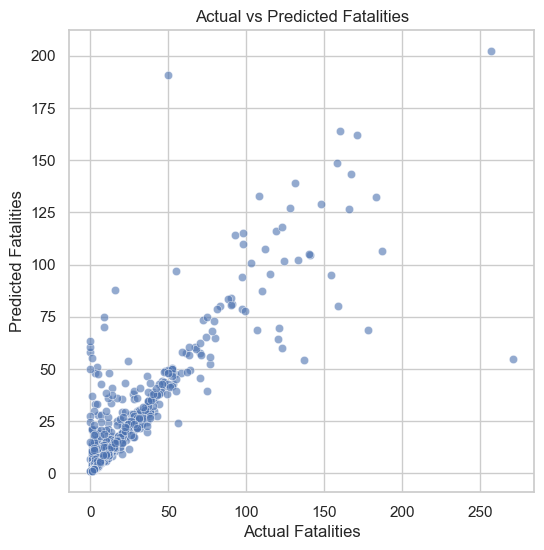

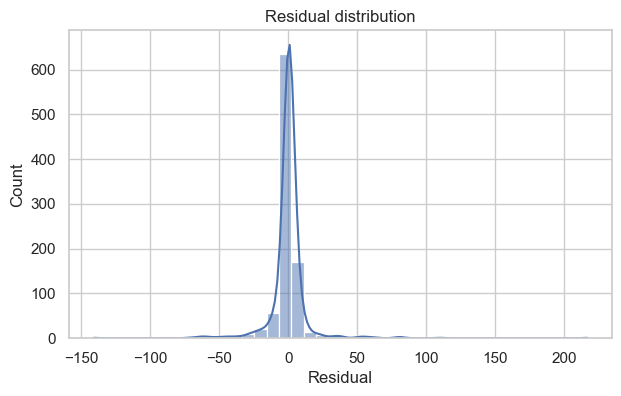

In [46]:
final_model = clone(selected_model)
final_model.fit(X_train_full, y_train_full)

raw_test_predictions = final_model.predict(X_test)
test_predictions = apply_prediction_bounds(raw_test_predictions, X_test)

final_metrics = regression_metrics(y_test, test_predictions)
display(pd.DataFrame([final_metrics]))

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=test_predictions, alpha=0.6)
plt.xlabel("Actual Fatalities")
plt.ylabel("Predicted Fatalities")
plt.title("Actual vs Predicted Fatalities")
plt.show()

residuals = y_test - test_predictions

plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Residual")
plt.title("Residual distribution")
plt.show()

## 21. Feature importance or coefficient interpretation

Feature importance is shown when the selected model exposes feature importances or coefficients.

,Feature,Importance
12,num__aboard_log1p,0.205877
15,num__total_exposed_log1p,0.169700
0,num__Aboard,0.168054
14,num__total_exposed,0.091727
23,num__location_near_flag,0.044618
592,summary_text__crashed,0.029453
22,num__remote_terrain_flag,0.026559
442,cat__aircraft_family_Boeing,0.022786
956,summary_text__taking,0.008876
41,num__summary_landing_takeoff_flag,0.008778


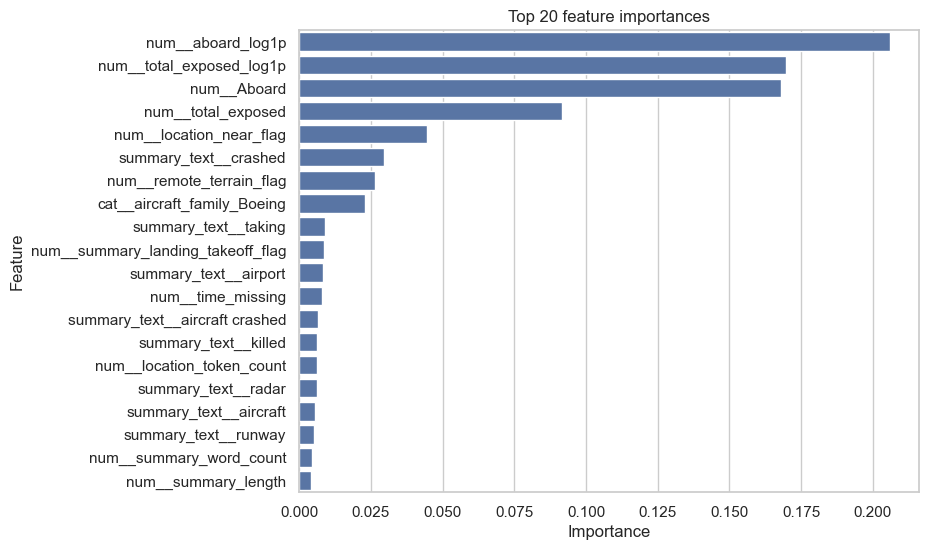

In [48]:
def extract_inner_pipeline(model):
    if isinstance(model, TransformedTargetRegressor):
        return model.regressor_
    return model


try:
    inner_model = extract_inner_pipeline(final_model)
    preprocessor_step = inner_model.named_steps["preprocessor"]
    regressor_step = inner_model.named_steps["regressor"]

    feature_names = preprocessor_step.get_feature_names_out()

    if hasattr(regressor_step, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": regressor_step.feature_importances_,
        }).sort_values("Importance", ascending=False)

        display(importance_df.head(25))

        plt.figure(figsize=(8, 6))
        sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
        plt.title("Top 20 feature importances")
        plt.show()

    elif hasattr(regressor_step, "coef_"):
        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient": regressor_step.coef_,
            "Absolute coefficient": np.abs(regressor_step.coef_),
        }).sort_values("Absolute coefficient", ascending=False)

        display(coef_df.head(25))

        plt.figure(figsize=(8, 6))
        sns.barplot(data=coef_df.head(20), x="Absolute coefficient", y="Feature")
        plt.title("Top 20 coefficients by absolute value")
        plt.show()

    else:
        print("The selected model does not expose coefficients or feature importances.")

except Exception as error:
    print("Feature interpretation could not be produced for this model.")
    print(error)

## 22. Refit final model on all labelled training data

After evaluation, the selected model is refit on all available labelled training data before generating predictions for the unseen dataset.

In [50]:
submission_model = clone(selected_model)
submission_model.fit(X, y)

print("Submission model refitted on all labelled training rows:", X.shape[0])

Submission model refitted on all labelled training rows: 4730


## 23. Predict unseen data

The final predictions are saved as a one-column CSV file named:

```text
Fenner_Backhouse_scenario_2.csv
```

This file is saved in the same folder as the notebook.

In [52]:
ROUND_PREDICTIONS = False

raw_unseen_predictions = submission_model.predict(unseen_df[feature_cols])
unseen_predictions = apply_prediction_bounds(raw_unseen_predictions, unseen_df)

if ROUND_PREDICTIONS:
    unseen_predictions = np.rint(unseen_predictions).astype(int)

predictions_df = pd.DataFrame({
    "Predictions": unseen_predictions
})

predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print("Predictions saved to:", PREDICTIONS_PATH)
print("Prediction file shape:", predictions_df.shape)

display(predictions_df.head())
display(predictions_df.describe())

assert list(predictions_df.columns) == ["Predictions"], "Output CSV must contain only the Predictions column."
assert len(predictions_df) == len(unseen_df), "Number of predictions must match the unseen dataset."

Predictions saved to: C:\Users\fenne\Documents\Rockborne_training\DS_Proj1\Fenner_Backhouse_scenario_2.csv
Prediction file shape: (527, 1)


,Predictions
0,7.252172
1,26.055804
2,150.004583
3,20.296799
4,21.047120


,Predictions
count,527.000000
mean,20.198520
std,27.899919
min,1.000000
25%,4.586985
50%,11.639243
75%,22.731343
max,206.899167


## 24. Conclusions

This notebook implements a complete regression workflow for predicting airplane crash fatalities.

The final process includes:

- data loading and validation
- missing-value checks
- target cleaning
- exploratory data analysis
- feature engineering
- preprocessing checks
- model comparison
- focused hyperparameter tuning
- internal test evaluation
- feature interpretation
- final prediction generation

The final model is selected using cross-validated R², while RMSE, MSE and MAE are also reported. The final predictions are bounded to satisfy basic validity constraints and saved in the required one-column format.